# JP/TW 太陽能預報 Parquet 資料結構探索

每個檔案 = 一次 ICON run 的匯出：**日本+台灣陸地格點 × 預報時長(7天逐時) × 13 個變數**。
檔名的時間戳 = 該輪 run 的執行時間（`init_time`），由 `run_jp_tw_solar.sh` 每 6 小時產生一個。

In [1]:
import pandas as pd
import glob, os

# 讀取最新一個 parquet
files = sorted(glob.glob('out/jp_tw_solar_*.parquet'))
f = files[-1]
df = pd.read_parquet(f)
print(f'檔案: {f}  ({os.path.getsize(f)/1e6:.1f} MB)')
print(f'列數: {len(df):,}   欄數: {len(df.columns)}')

檔案: out/jp_tw_solar_20260612T033555Z.parquet  (19.3 MB)
列數: 1,817,856   欄數: 18


## 1. Schema：一列 = 一個格點在某一小時 (long/tidy format)

- 5 個定位欄：`location_id, latitude, longitude, elevation, time`
- 13 個變數欄：欄名格式為 `變數_單位`

In [2]:
df.dtypes.to_frame('dtype')

,dtype
location_id,int64
latitude,float32
longitude,float32
elevation,float32
time,datetime64[ms]
shortwave_radiation_wattPerSquareMetre,float32
direct_radiation_wattPerSquareMetre,float32
diffuse_radiation_wattPerSquareMetre,float32
direct_normal_irradiance_wattPerSquareMetre,float32
temperature_2m_celsius,float32


In [3]:
df.head(8)

,location_id,latitude,longitude,elevation,time,shortwave_radiation_wattPerSquareMetre,direct_radiation_wattPerSquareMetre,diffuse_radiation_wattPerSquareMetre,direct_normal_irradiance_wattPerSquareMetre,temperature_2m_celsius,relative_humidity_2m_percentage,wind_speed_10m_metrePerSecond,surface_pressure_hectopascal,precipitation_millimetre,cloud_cover_percentage,cloud_cover_low_percentage,cloud_cover_mid_percentage,cloud_cover_high_percentage
0,2581990,22.0,120.75,30.0,2026-06-12 00:00:00,72.0,0.0,72.0,0.000000,26.000000,90.0,1.345362,1012.900024,1.8,100.0,79.0,77.0,100.0
1,2581990,22.0,120.75,30.0,2026-06-12 01:00:00,135.0,0.0,135.0,0.000000,26.250000,90.0,1.208305,1013.000000,1.2,100.0,83.0,52.0,100.0
2,2581990,22.0,120.75,30.0,2026-06-12 02:00:00,237.0,29.0,208.0,34.983932,27.000000,87.0,1.264911,1012.799988,0.0,100.0,81.0,59.0,100.0
3,2581990,22.0,120.75,30.0,2026-06-12 03:00:00,298.0,34.0,264.0,36.279247,27.299999,86.0,1.843909,1012.599976,1.1,100.0,81.0,61.0,100.0
4,2581990,22.0,120.75,30.0,2026-06-12 04:00:00,324.0,32.0,292.0,32.271893,27.100000,88.0,2.325941,1012.299988,1.9,100.0,79.0,62.0,100.0
5,2581990,22.0,120.75,30.0,2026-06-12 05:00:00,292.0,28.0,264.0,28.327181,27.049999,89.0,2.473863,1011.799988,2.0,100.0,85.0,61.0,100.0
6,2581990,22.0,120.75,30.0,2026-06-12 06:00:00,241.0,10.0,231.0,10.775676,27.000000,90.0,2.927456,1011.500000,2.5,100.0,76.0,67.0,100.0
7,2581990,22.0,120.75,30.0,2026-06-12 07:00:00,210.0,4.0,206.0,4.911634,27.049999,89.0,3.301515,1011.099976,1.8,100.0,73.0,66.0,100.0


## 2. 資料範圍與規模

In [4]:
print(f'格點數      : {df.location_id.nunique():,} (日台陸地)')
print(f'時間範圍(UTC): {df.time.min()} ~ {df.time.max()}')
print(f'每點時間步   : {len(df)//df.location_id.nunique()} 小時')
print(f'緯度         : {df.latitude.min()} ~ {df.latitude.max()}')
print(f'經度         : {df.longitude.min()} ~ {df.longitude.max()}')
print(f'高程         : {df.elevation.min():.0f} ~ {df.elevation.max():.0f} m')

格點數      : 9,468 (日台陸地)
時間範圍(UTC): 2026-06-12 00:00:00 ~ 2026-06-19 23:00:00
每點時間步   : 192 小時
緯度         : 22.0 ~ 46.0
經度         : 120.0 ~ 150.0
高程         : 1 ~ 2482 m


In [5]:
# 各變數的數值範圍與缺值率
meta_cols = ['location_id','latitude','longitude','elevation','time']
stats = df.drop(columns=meta_cols).agg(['min','max','mean']).T
stats['NaN%'] = df.drop(columns=meta_cols).isna().mean().mul(100).round(1)
stats.round(1)

,min,max,mean,NaN%
shortwave_radiation_wattPerSquareMetre,0.000000,1059.000000,224.800003,12.0
direct_radiation_wattPerSquareMetre,0.000000,951.000000,122.000000,12.0
diffuse_radiation_wattPerSquareMetre,0.000000,515.000000,102.800003,12.0
direct_normal_irradiance_wattPerSquareMetre,0.000000,4194.299805,175.000000,12.0
temperature_2m_celsius,4.000000,34.700001,19.900000,12.0
relative_humidity_2m_percentage,12.000000,100.000000,76.199997,12.0
wind_speed_10m_metrePerSecond,0.000000,10.900000,2.100000,12.0
surface_pressure_hectopascal,999.200012,1021.400024,1011.000000,12.0
precipitation_millimetre,0.000000,35.900002,0.200000,12.0
cloud_cover_percentage,0.000000,100.000000,78.300003,12.0


## 3. init_time 與 lead time

檔名時間戳 = 這輪 run 的 `init_time`。`time` 欄 − `init_time` = **lead time**（預報提前量）。
存下每一輪的檔案，就累積出 `init_time × lead_time` 的訓練資料結構。

In [6]:
import re
from datetime import datetime, timezone

m = re.search(r'(\d{8}T\d{6}Z)', f)
init_time = pd.Timestamp(datetime.strptime(m.group(1), '%Y%m%dT%H%M%SZ'))
df['lead_hours'] = (df.time - init_time).dt.total_seconds() / 3600
print(f'init_time : {init_time}')
print(f'lead time : {df.lead_hours.min():.0f} ~ {df.lead_hours.max():.0f} 小時')

init_time : 2026-06-12 03:35:55
lead time : -4 ~ 187 小時


## 4. 單一格點的 7 天時序（台灣，UTC+8）

/var/folders/44/zm3slchs2h799jld54842r4w0000gn/T/ipykernel_50716/2443145897.py:19: UserWarning: Glyph 21488 (\N{CJK UNIFIED IDEOGRAPH-53F0}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/44/zm3slchs2h799jld54842r4w0000gn/T/ipykernel_50716/2443145897.py:19: UserWarning: Glyph 28771 (\N{CJK UNIFIED IDEOGRAPH-7063}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/44/zm3slchs2h799jld54842r4w0000gn/T/ipykernel_50716/2443145897.py:19: UserWarning: Glyph 26178 (\N{CJK UNIFIED IDEOGRAPH-6642}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/44/zm3slchs2h799jld54842r4w0000gn/T/ipykernel_50716/2443145897.py:19: UserWarning: Glyph 38291 (\N{CJK UNIFIED IDEOGRAPH-9593}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/Users/wctseng/miniconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21488 (\N{CJK UNIFIED IDEOGRAPH-53F0}) missing from font(s) De

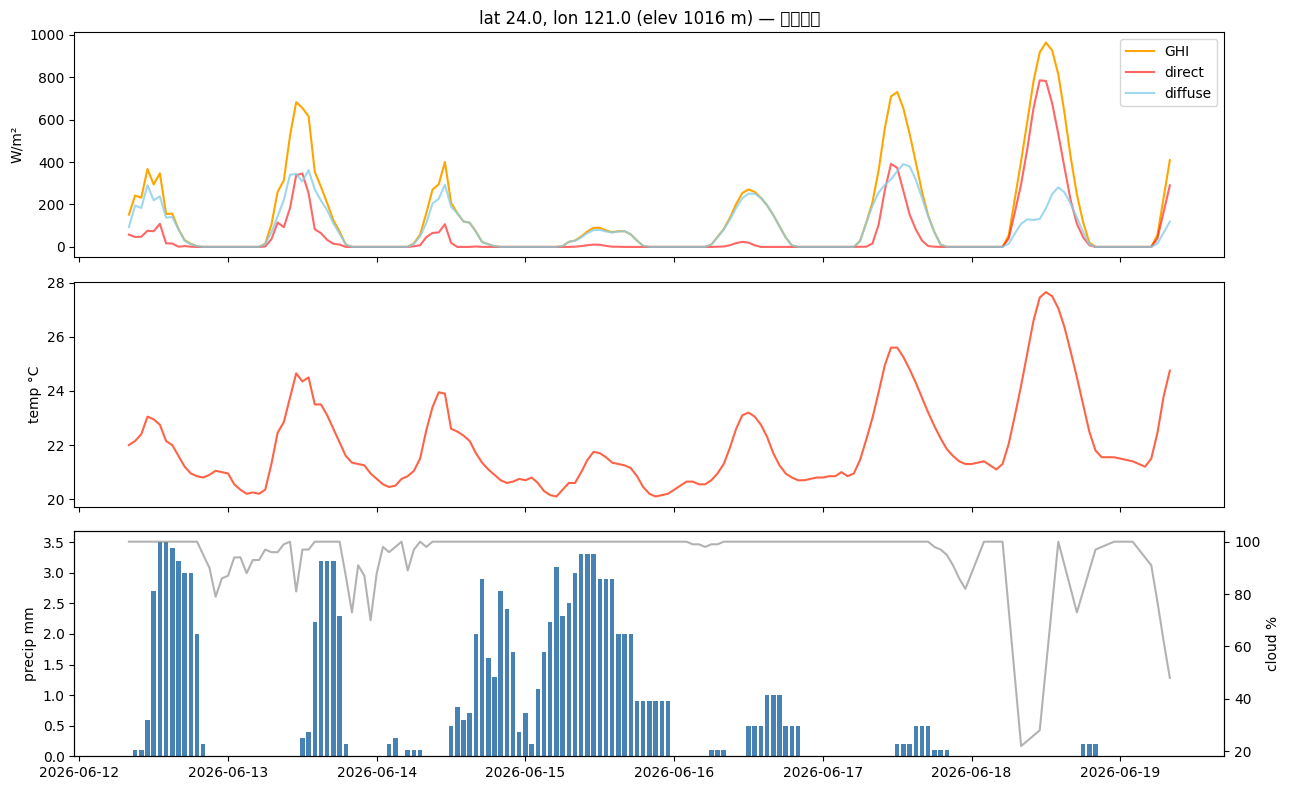

In [7]:
import matplotlib.pyplot as plt

# 挑一個台灣中部的格點
tw = df[(df.latitude==24.0) & (df.longitude==121.0)].sort_values('time').copy()
tw['time_tw'] = tw.time + pd.Timedelta(hours=8)

ghi = 'shortwave_radiation_wattPerSquareMetre'
fig, axes = plt.subplots(3, 1, figsize=(13, 8), sharex=True)
axes[0].plot(tw.time_tw, tw[ghi], color='orange', label='GHI')
axes[0].plot(tw.time_tw, tw['direct_radiation_wattPerSquareMetre'], color='red', alpha=.6, label='direct')
axes[0].plot(tw.time_tw, tw['diffuse_radiation_wattPerSquareMetre'], color='skyblue', alpha=.8, label='diffuse')
axes[0].set_ylabel('W/m²'); axes[0].legend(); axes[0].set_title(f'lat 24.0, lon 121.0 (elev {tw.elevation.iloc[0]:.0f} m) — 台灣時間')
axes[1].plot(tw.time_tw, tw['temperature_2m_celsius'], color='tomato')
axes[1].set_ylabel('temp °C')
axes[2].bar(tw.time_tw, tw['precipitation_millimetre'], width=.03, color='steelblue', label='precip')
ax2 = axes[2].twinx()
ax2.plot(tw.time_tw, tw['cloud_cover_percentage'], color='gray', alpha=.6, label='cloud')
axes[2].set_ylabel('precip mm'); ax2.set_ylabel('cloud %')
plt.tight_layout(); plt.show()

## 5. 空間分布：正午的 GHI 地圖（確認涵蓋日台）

/var/folders/44/zm3slchs2h799jld54842r4w0000gn/T/ipykernel_50716/1871622348.py:8: UserWarning: Glyph 21488 (\N{CJK UNIFIED IDEOGRAPH-53F0}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/44/zm3slchs2h799jld54842r4w0000gn/T/ipykernel_50716/1871622348.py:8: UserWarning: Glyph 28771 (\N{CJK UNIFIED IDEOGRAPH-7063}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/44/zm3slchs2h799jld54842r4w0000gn/T/ipykernel_50716/1871622348.py:8: UserWarning: Glyph 27491 (\N{CJK UNIFIED IDEOGRAPH-6B63}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/44/zm3slchs2h799jld54842r4w0000gn/T/ipykernel_50716/1871622348.py:8: UserWarning: Glyph 21320 (\N{CJK UNIFIED IDEOGRAPH-5348}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/Users/wctseng/miniconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 27491 (\N{CJK UNIFIED IDEOGRAPH-6B63}) missing from font(s) DejaVu

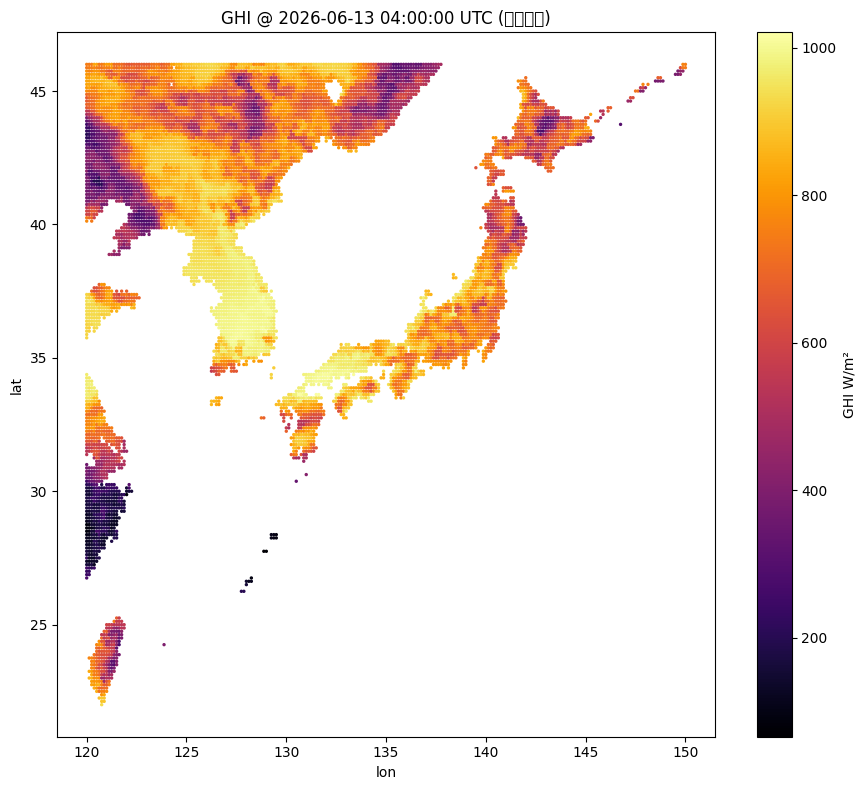

In [8]:
# 取台灣正午(UTC 04:00)那個時間步的全部格點
snap = df[df.time == df.time.min() + pd.Timedelta(hours=28)]  # day2 12:00 台灣時間
fig, ax = plt.subplots(figsize=(9, 8))
sc = ax.scatter(snap.longitude, snap.latitude, c=snap[ghi], s=2, cmap='inferno')
plt.colorbar(sc, label='GHI W/m²')
ax.set_title(f'GHI @ {snap.time.iloc[0]} UTC (台灣正午)')
ax.set_xlabel('lon'); ax.set_ylabel('lat')
plt.tight_layout(); plt.show()

## 6. 常用查詢範例

```python
# 找某案場最近的格點
site_lat, site_lon = 23.5, 120.45
d2 = (df.latitude-site_lat)**2 + (df.longitude-site_lon)**2
nearest = df[d2 == d2.min()]

# 多檔合併成 init_time × lead_time 訓練集
frames = []
for path in sorted(glob.glob('out/jp_tw_solar_*.parquet')):
    t = pd.Timestamp(datetime.strptime(re.search(r'(\d{8}T\d{6}Z)', path).group(1), '%Y%m%dT%H%M%SZ'))
    d = pd.read_parquet(path); d['init_time'] = t
    frames.append(d)
archive = pd.concat(frames)
```

## 7. GHI 動畫：整段預報期間的時空變化

每幀 = 一個小時的日台 GHI 地圖。輸出 `out/ghi_animation.gif`。


In [9]:
import numpy as np
from matplotlib.animation import FuncAnimation, PillowWriter

dfa = df.dropna(subset=[ghi])
times = np.sort(dfa.time.unique())
pts = dfa[['location_id','latitude','longitude']].drop_duplicates('location_id').sort_values('location_id')
wide = dfa.pivot(index='location_id', columns='time', values=ghi).loc[pts.location_id]

fig, ax = plt.subplots(figsize=(7.5, 6.8))
sc = ax.scatter(pts.longitude, pts.latitude, c=wide.iloc[:,0], s=2.5, cmap='inferno', vmin=0, vmax=1000)
plt.colorbar(sc, label='GHI W/m²')
ax.set_xlabel('lon'); ax.set_ylabel('lat')
title = ax.set_title('')

def update(i):
    sc.set_array(wide.iloc[:, i].values)
    t = pd.Timestamp(times[i])
    title.set_text(f'GHI  {t:%m-%d %H:%M} UTC  (TW {t+pd.Timedelta(hours=8):%H:%M} / JP {t+pd.Timedelta(hours=9):%H:%M})')
    return sc, title

anim = FuncAnimation(fig, update, frames=len(times), blit=False)
anim.save('out/ghi_animation.gif', writer=PillowWriter(fps=10), dpi=72)
plt.close()
print('saved out/ghi_animation.gif')

saved out/ghi_animation.gif


## 8. APAC 完整矩形版 GHI 動畫

讀取最新的 `apac_solar_*.parquet`（單一大框 lat −44~46、lon 92~154，由 `run_solar_regions.sh` 產生），
輸出 `out/ghi_animation_apac.gif`。與第 7 節的差別：涵蓋日台＋東南亞＋澳洲＋中國內陸，無缺角、無框重疊。


In [10]:
import numpy as np
from matplotlib.animation import FuncAnimation, PillowWriter

ghi = 'shortwave_radiation_wattPerSquareMetre'
apac_file = sorted(glob.glob('out/apac_solar_*.parquet'))[-1]
dfa = pd.read_parquet(apac_file, columns=['location_id','latitude','longitude','time',ghi])
print('file:', apac_file)

# 只取「95% 以上點有值」的時間步，避開預報時長截斷的 NaN 尾巴
valid = dfa.groupby('time')[ghi].apply(lambda s: s.notna().mean())
times = np.sort(valid[valid > 0.95].index.values)
dfa = dfa[dfa.time.isin(times)]
print(f'{len(times)} timesteps, {dfa.location_id.nunique():,} points')

pts = dfa[['location_id','latitude','longitude']].drop_duplicates('location_id').sort_values('location_id')
wide = dfa.pivot(index='location_id', columns='time', values=ghi).loc[pts.location_id]

fig, ax = plt.subplots(figsize=(7.2, 9.5))
sc = ax.scatter(pts.longitude, pts.latitude, c=wide.iloc[:,0], s=1.0, cmap='inferno', vmin=0, vmax=1000)
plt.colorbar(sc, label='GHI W/m²', shrink=.6)
ax.set_xlabel('lon'); ax.set_ylabel('lat')
# 先放兩行佔位標題再 tight_layout，版面才會為兩行標題預留高度（否則會被裁切）
title = ax.set_title('GHI\n ')
plt.tight_layout()

def update(i):
    sc.set_array(wide.iloc[:, i].values)
    t = pd.Timestamp(times[i])
    title.set_text(f'GHI  {t:%m-%d %H:%M} UTC\n(TW {t+pd.Timedelta(hours=8):%H:%M} / JP {t+pd.Timedelta(hours=9):%H:%M} / AEST {t+pd.Timedelta(hours=10):%H:%M})')
    return sc, title

anim = FuncAnimation(fig, update, frames=len(times), blit=False)
anim.save('out/ghi_animation_apac.gif', writer=PillowWriter(fps=10), dpi=66)
plt.close()
print('saved out/ghi_animation_apac.gif')

file: out/apac_solar_20260612T041103Z.parquet


181 timesteps, 120,399 points


saved out/ghi_animation_apac.gif
